# Exercise 1
### Computer Vision, Fall 2026
#### Name: <font color='blue'>*Sepeteus Rosenlöf*</font>
---
**Instructions:**
- Return the answer in PDF and Jupyter Notebook formats.

- Return latest on<font color='red'> Wednesday 9.9 at 16.00</font> via Moodle.

**Requirements:**

In this exercise you will need the following python packages:
- numpy
- matplotlib
- opencv-python

## Exercise 1.1: Homogeneous Coordinates and 2D Transformations (3 Points)

During the lecture you have learned about affine and projective transformations. These two types of transformations preserve different properties of space. For example affine transformations preserve line parallelism, while projective transformations don't. When working with with these transformations, we usually rely on **homogenous coordinates**. They are essential when working with geometry in computer vision and generally make calculations easier. Here is an example:

The affine transformation for points in Cartesian coordinates can be written as:

$$\textbf{y} = A\textbf{x} + \textbf{b}$$

Notice that there are two operations: multiplication and addition. This means that applying two operations in a row can't be easily combined into one operation.
Now, when we use **homogenous coordinates** the same equation becomes:

$$\textbf{\~y} = A'\textbf{\~x}$$
with

$$A' = \begin{bmatrix}A & b \\ 0 & 1 \\ \end{bmatrix}$$

This representation greatly simplifies application of transformations. Consequent transformations can now be combined in one single matrix.

Your tasks are:

#### a) Affine transformation

- Write down a matrix M of an affine transformation, as a combination of a translation, scaling and rotation matrices. The details of the transformations are given below. 

- Apply the affine transformation to a set of points that are the vertices of an arrow-like shape. 

- Rotate the arrow by 90º counterclockwise, scale the x component by 2 and the y component by 0.5, and translate x by one unit to the right and y by one unit down. The transformations should be performed in the order: rotation, scaling, translation.

In [2]:
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
import numpy as np

In [4]:
# Fill in the matrices below
T = np.array([
    [1, 0, 1],
    [0, 1, -1],
    [0, 0, 1],
    ])
S = np.array([
    [2,0,0],
    [0,0.5,0],
    [0,0,1],
    
])
R = np.array(
    [[np.cos(np.radians(90)), -np.sin(np.radians(90)), 0],
    [np.sin(np.radians(90)), np.cos(np.radians(90)),  0],
    [0, 0, 1]]
)

M = T@S@R # Define M
M

array([[ 1.2246468e-16, -2.0000000e+00,  1.0000000e+00],
       [ 5.0000000e-01,  3.0616170e-17, -1.0000000e+00],
       [ 0.0000000e+00,  0.0000000e+00,  1.0000000e+00]])

In [91]:
# Definition of the arrow-like polygon in homogenous coordinates, DON'T MODIFY
arrow_vertices = np.array(
    [
        [0.0, -0.3, 1.0],  # Bottom back
        [1.0, -0.3, 1.0],  # Bottom neck
        [1.0, -0.7, 1.0],  # Bottom wing
        [2.0, 0.0, 1.0],  # Tip
        [1.0, 0.7, 1.0],  # Top wing
        [1.0, 0.3, 1.0],  # Top neck
        [0.0, 0.3, 1.0],  # Top back
    ]
).T  # Shape: (3, N)

Below we provide you a helper function `plot_polygon(vertices, M)` that plots a polygon given a np.array with vertices. The function also needs the transformation matrix M as input. If the cell runs succesfully you will see a plot of the original arrow.

The original arrow shape


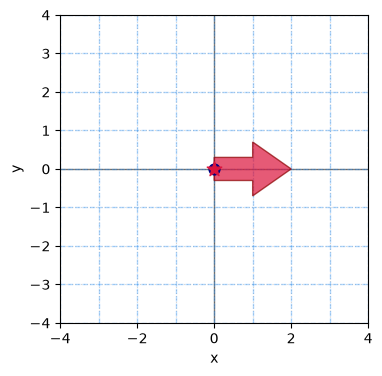

In [6]:
### Run this cell to load the helper function, DON'T MODIFY
def plot_polygon(vertices: np.ndarray, M: np.ndarray):
    """Plot a polygon in a coordinate grid
    
    Parameters:
        vertices: np.array with vertices of the polygon in homogenous coordinates
        M: transformation matrix
    """

    # Create grid lines
    grid_lines = []
    grid_range = np.linspace(-4, 4, 9)

    for v in grid_range:
        # Vertical line segment
        grid_lines.append(np.array([[v, v], [-4, 4], [1, 1]]))
        # Horizontal line segment
        grid_lines.append(np.array([[-4, 4], [v, v], [1, 1]]))

    # Transform grid lines
    grid_lines_transformed = [M @ line for line in grid_lines]

    for j, line in enumerate(grid_lines_transformed):
        for i, ele in enumerate(line):
            ele = [ele[0] / line[2][0], ele[1] / line[2][1]]
            line[i] = ele
        grid_lines_transformed[j] = line

    # Plotting
    _fig, _ax = plt.subplots(figsize=(4, 4))

    # Plot initial background grid (static)
    for line in grid_lines:
        _ax.plot(
            line[0],
            line[1],
            color="lightgray",
            linestyle=":",
            linewidth=0.8,
            zorder=1,
        )

    # Plot transformed space grid
    for line in grid_lines_transformed:
        _ax.plot(
            line[0],
            line[1],
            color="dodgerblue",
            linestyle="--",
            alpha=0.35,
            linewidth=1.0,
            zorder=2,
        )

    # Draw polygon
    trans_coords = vertices[:2].T
    trans_patch = Polygon(
        trans_coords,
        closed=True,
        facecolor="crimson",
        edgecolor="darkred",
        alpha=0.7,
        zorder=4,
    )
    _ax.add_patch(trans_patch)

    # Highlight origin shifts
    origin_orig = np.array([0.0, 0.0, 1.0])
    origin_trans = M @ origin_orig

    _ax.scatter(
        [0], [0], color="navy", marker="o", s=60, label="Original Origin", zorder=5
    )
    _ax.scatter(
        [origin_trans[0]],
        [origin_trans[1]],
        color="crimson",
        marker="*",
        s=120,
        label="Shifted Origin",
        zorder=5,
    )

    # Formatting
    _ax.set_xlim(-4, 4)
    _ax.set_ylim(-4, 4)
    _ax.set_xlabel("x")
    _ax.set_ylabel("y")
    _ax.set_aspect("equal")
    _ax.axhline(0, color="black", linewidth=1.0, alpha=0.5, zorder=1)
    _ax.axvline(0, color="black", linewidth=1.0, alpha=0.5, zorder=1)
    _ax.grid(False)
    plt.show()

print("The original arrow shape")
plot_polygon(arrow_vertices, np.eye(3))

Apply the transformation matrix to the arrow vertices in the code cell below. Plot the transformed arrow.

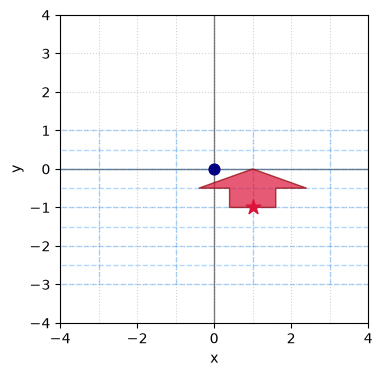

In [7]:

plot_polygon(M@arrow_vertices, M)

#### b) Projective transformation
- Define a second transformation matrix, which encodes a projective transformation such that it visibly breaks line parallelism. You can choose any projective transformation.

- Apply the transformation to the set of arrow vertices and plot the result.

Hint:

Projective transformations need an additional step after application that relates to the representation of homogenous coordinates.

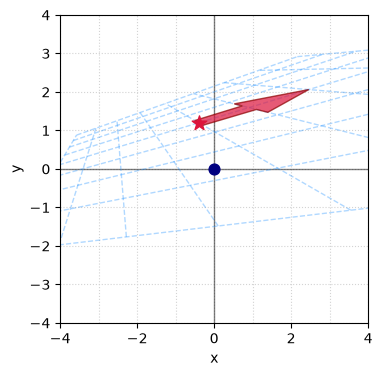

(None,)

In [178]:
#Translation
T = np.array([
    [1, 0, -2],
    [0, 1, 1.2],
    [0, 0, 1],
    ])
#Shear
S = np.array([
    [1,2,0],
    [1.2,1,0],
    [0,0,1],
    
])
#Rotation
R = np.array(
    [[np.cos(np.radians(180)), -np.sin(np.radians(180)), 0],
    [np.sin(np.radians(180)), np.cos(np.radians(180)),  0],
    [0, 0, 1]]
)
# #Reflection
F = np.array(
    [[np.cos(2*np.radians(30)), -np.sin(2*np.radians(240)), 0],
    [np.sin(2*np.radians(120)), np.cos(2*np.radians(25)),  0],
    [0, 0, 1]]
)

M2 = R @ S @ T @ F
M2[2][0] = -0.08
M2[2][1] = 0.16


#other solution
# M2 = np.array([
#     [1,0,0],
#     [0,1,0],
#     [0.2,0.3,1]
# ])
new_arrow_vertices = M2@arrow_vertices
new_arrow_vertices /= new_arrow_vertices[2, :]
plot_polygon(new_arrow_vertices, M2),
#T@S@R # Define M

#### b) Homogeneous line

1) Give the formula for presenting a homogeneous coordinate as a line. Plot the homogeneous lines $l_1$ and $l_2$ in a 2D coordinate system where $l_1 = (1,0,1)$ and $l_2 = (6,0,2)$. Describe what the lines look like.

2) Calculate the point where the homogeneous lines $l_1$ and $l_2$ join. Are you able to plot the line in a 2D plot? Give an explanation for the result.

Hint:

 - the (3x1) homogenous point vector x must satisfy both $I_1^Tx = 0$ and $I_2^Tx = 0$. In other words, it should be orthogonal to both $I_1$ and $I_2$.

    Answer:
    
1)

2)

## Ex 1.2 OpenCV basics and image manipulation with Python (2 points)

In this exercise we’ll start learning how to use Python and OpenCV for computer vision tasks.

In [1]:
# Import Python packages needed in this week exercises. 
from matplotlib import pyplot as plt
import numpy as np
import cv2

#### 1.2 a)

- Load the image located at 'images/lapland.jpeg'.
- State the shape (dimensions) of the image.
- Display the original image and each of its three color channels (Blue, Green, and Red) separately.

Hint: 

- By default, OpenCV's `imread` function reads images in BGR format, while Matplotlib displays images in RGB format. 
    - You can use OpenCV's `cv2.cvtColor(img, cv2.COLOR_BGR2RGB)` to convert the image from BGR to RGB.
- Images containing a single color channel are typically displayed using a grayscale colormap.
    - In matplotlib, you can use the parameter `cmap='gray'` to achieve this.

In [3]:
# Answer here

#### 1.2 b)
- Load the image located at 'images/lapland.jpeg'.
- Convert the image to grayscale.
- Define a transformation matrix M that rotates an image by 90º.
- Rotate the image using the transformation matrix M and plot the image. The whole image needs to be visible.

The image below illustrates the coordinate system employed in this exercise, which is also frequently utilized in computer vision.


Hints:

- You can use OpenCV warpPerspective function
- Think about coordinates used in computer vision (shown on image below). You may need to perform other transformations in order to rotate the image around it's center.
<img src="images/image_coordinates.png" width="350" align="center">

In [3]:
# Answer here


## Ex 1.3 Singular Value Decomposition (SVD) (3 points)

Singular Value Decomposition (SVD): Every $m \times p$ matrix factors into $A_{n \times p} = U_{n \times n} \Sigma_{n \times p} V^T_{p \times p}$

Singular Value Decomposition can be used for image compression by first applying SVD to the image matrix and then recomposing it by using only some of the singular values contained in matrix $\Sigma_{n \times p}$ and dropping the respective columns and rows in matrices $U_{n \times n}$ and $V^T_{p \times p}$ in order to make the matrices compatible for recomposing the image matrix.

Try this for yourself by decomposing images/lenna.png (open the image as grayscale) with SVD, and then recompose the image by using only the first 50 singular values (you can use the ready-made SVD function in numpy.linalg library, no need to implement it from scratch unless you want to). Also try using different number of singular values. How many singular values are needed before the image no longer appears blurry (Optional extra: how is the image size changed, i.e how much memory you save by compressing the image)?

Explain why this method of image compression works, what is the role of singular values and what information they contain? Brief explanation is enough for this assignment.

In [ ]:
# Answer here